# 02 — Training

Ziel: Training mit MobileNetV2 Transfer Learning erklären, Trainingsverlauf dokumentieren und Modellentscheidung nachvollziehbar machen.

**Finales Modell:** `models/freshify_baseline_with_new_raw.keras`  
**Architektur:** MobileNetV2 Backbone + binärer Kopf (Sigmoid)  
**Loss:** `binary_crossentropy` | **Optimizer:** `adam`

### Aufbau
1. Setup & Modellarchitektur
2. Finales Modell laden
3. Datasets (wie in `train.py`)
4. Optionaler Trainingslauf
5. Trainingshistorien & Kurven
6. Modell-Vergleich & Pipeline
7. Detector-Kontext

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import tensorflow as tf
    from tensorflow.keras import layers, models
    from tensorflow.keras.applications import MobileNetV2
    from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
    from tensorflow.keras.utils import image_dataset_from_directory
except ImportError as exc:
    tf = None
    print(f"TensorFlow ist nicht installiert: {exc}")

def find_project_root(start=Path.cwd()):
    for path in [start, *start.parents]:
        if (path / "pyproject.toml").exists() and (path / "src").exists():
            return path
    raise RuntimeError("Projekt-Root nicht gefunden.")

PROJECT_ROOT = find_project_root()
DATA_DIR     = PROJECT_ROOT / "data"
TRAIN_DIR    = DATA_DIR / "train"
VAL_DIR      = DATA_DIR / "val"
REPORTS_DIR  = PROJECT_ROOT / "reports"
MODELS_DIR   = PROJECT_ROOT / "models"
FINAL_MODEL  = MODELS_DIR / "freshify_baseline_with_new_raw.keras"

# Entspricht den Trainingsparametern in train.py
IMG_SIZE   = (224, 224)
BATCH_SIZE = 8
EPOCHS     = 10
BUILD_DEMO_MODEL = False

plt.style.use("default")
pd.set_option("display.max_colwidth", 120)

## 1. Modellarchitektur

Die Architektur entspricht fachlich dem Modellaufbau in `train.py`:

- **Backbone:** MobileNetV2, vortrainiert auf ImageNet, `trainable=False`
- **Preprocessing:** `mobilenet_v2.preprocess_input` (skaliert Pixel auf [-1, 1])
- **Kopf:** `GlobalAveragePooling2D` → `Dropout(0.2)` → `Dense(1, sigmoid)`
- **Eingabe:** 224 × 224 × 3

In [2]:
def build_transfer_model(input_shape=(224, 224, 3)):
    """Baut das MobileNetV2-Transfer-Learning-Modell analog zu train.py."""
    if tf is None:
        raise RuntimeError("TensorFlow wird benötigt.")
    base_model = MobileNetV2(
        name="mobilenet_v2",
        weights="imagenet",
        include_top=False,
        input_shape=input_shape,
    )
    base_model.trainable = False

    inputs  = layers.Input(shape=input_shape)
    x       = preprocess_input(inputs)
    x       = base_model(x, training=False)
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.Dropout(0.2)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)
    model   = models.Model(inputs, outputs)
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return model

if BUILD_DEMO_MODEL and tf is not None:
    demo_model = build_transfer_model()
    demo_model.summary()
else:
    print("Demo-Modell nicht gebaut. Setze BUILD_DEMO_MODEL=True, wenn die Architektur neu initialisiert werden soll.")

Demo-Modell nicht gebaut. Setze BUILD_DEMO_MODEL=True, wenn die Architektur neu initialisiert werden soll.


## 2. Finales Modell laden

`models/freshify_baseline_with_new_raw.keras` wird geladen und die Architektur bestätigt.
Die `summary()` sollte identisch mit `build_transfer_model()` oben sein.

In [3]:
if tf is not None and FINAL_MODEL.exists():
    final_model = tf.keras.models.load_model(FINAL_MODEL)
    print(f"Modell geladen: {FINAL_MODEL}")
    final_model.summary()
else:
    print(f"Modell nicht gefunden: {FINAL_MODEL}")

Modell geladen: /Users/timwalther/food_freshness/models/freshify_baseline_with_new_raw.keras


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,261,829 (8.63 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 2,564 (10.02 KB)

## 3. Datasets

Analog zu `train.py`: `image_dataset_from_directory`, `label_mode="binary"`, Shuffle nur für Train, `prefetch` mit `AUTOTUNE`.

Wichtig: Bei alphabetischer Ordnerreihenfolge ist `edible=0` und `non_edible=1`.

In [4]:
if tf is not None and TRAIN_DIR.exists() and VAL_DIR.exists():
    train_dataset = image_dataset_from_directory(
        TRAIN_DIR,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        label_mode="binary",
        shuffle=True,
    )
    val_dataset = image_dataset_from_directory(
        VAL_DIR,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        label_mode="binary",
        shuffle=False,
    )
    class_names = train_dataset.class_names
    print("Classes:", class_names)
    print("Wichtig: edible=0, non_edible=1 (alphabetisch).")
    train_dataset = train_dataset.prefetch(buffer_size=tf.data.AUTOTUNE)
    val_dataset   = val_dataset.prefetch(buffer_size=tf.data.AUTOTUNE)
else:
    print("Datasets nicht geladen — TensorFlow oder data/train / data/val fehlt.")

Found 480 files belonging to 2 classes.
Found 62 files belonging to 2 classes.
Classes: ['edible', 'non_edible']
Wichtig: edible=0, non_edible=1 (alphabetisch).


## 4. Optionaler Trainingslauf

Standardmäßig deaktiviert, damit kein Modell versehentlich ins Repo geschrieben wird.
Für einen neuen Lauf: `RUN_TRAINING = True` und `SAVE_MODEL` bewusst prüfen.

Das Log-Format und der Speicherpfad entsprechen exakt `train.py`.

In [5]:
RUN_TRAINING = False
SAVE_MODEL   = False

if RUN_TRAINING and tf is not None:
    model   = build_transfer_model()
    backbone_name = model.get_layer("mobilenet_v2").name
    history = model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=EPOCHS,
    )
    keys = history.history
    log_text = f"""
=== Training completed. ===
Model: {backbone_name}
Dataset: {len(train_dataset) * BATCH_SIZE} train samples, {len(val_dataset) * BATCH_SIZE} val samples
Epochs: {history.params['epochs']} | Steps per epoch: {history.params['steps']}
Total training time: {len(keys['loss'])} epochs

Final training loss: {keys['loss'][-1]:.4f}
Final training accuracy: {keys['accuracy'][-1]:.4f}

Final validation loss: {keys['val_loss'][-1]:.4f}
Final validation accuracy: {keys['val_accuracy'][-1]:.4f}
"""
    print(log_text)
    if SAVE_MODEL:
        save_path = MODELS_DIR / f"{backbone_name}_classifier.keras"
        model.save(save_path)
        print(f"Modell gespeichert → {save_path}")
        Path("logs/training.log").parent.mkdir(parents=True, exist_ok=True)
        with open("logs/training.log", "a") as f:
            f.write(log_text)
            print("Saved training log → logs/training.log")
else:
    print("Training deaktiviert. Dieses Notebook nutzt gespeicherte histories.")

Training deaktiviert. Dieses Notebook nutzt gespeicherte histories.


## 5. Trainingshistorien laden & Kurven

Aus `reports/` werden die gespeicherten `history.json`-Dateien geladen.

In [6]:
history_paths = {
    "Baseline nach Data Cleanup": REPORTS_DIR / "freshify_baseline_after_data_cleanup" / "history.json",
    "Baseline mit new_raw":       REPORTS_DIR / "freshify_baseline_with_new_raw"       / "history.json",
}

def load_history(path):
    if not path.exists():
        return None
    with path.open("r", encoding="utf-8") as f:
        data = json.load(f)
    if "history" in data and isinstance(data["history"], dict):
        data = data["history"]
    return pd.DataFrame(data)

histories = {name: load_history(path) for name, path in history_paths.items()}
for name, hist in histories.items():
    print(f"{name}: {'gefunden' if hist is not None else 'fehlt'}")

Baseline nach Data Cleanup: gefunden
Baseline mit new_raw: gefunden


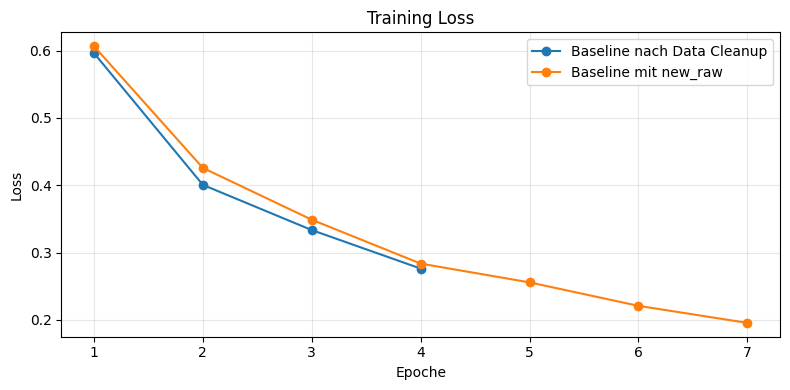

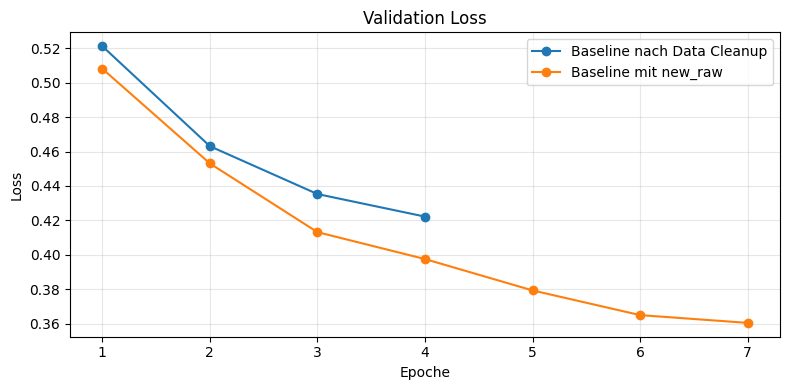

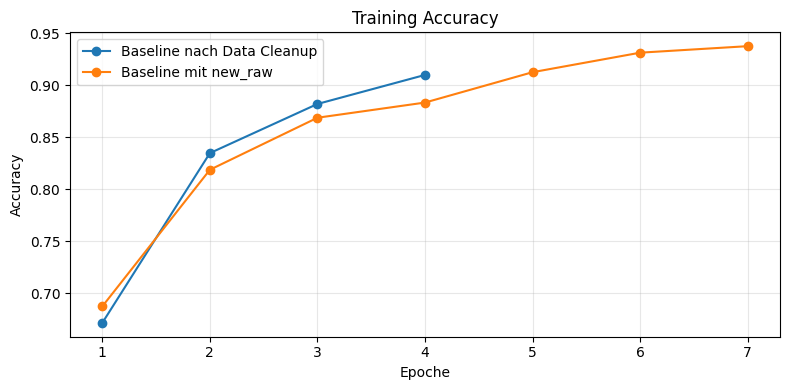

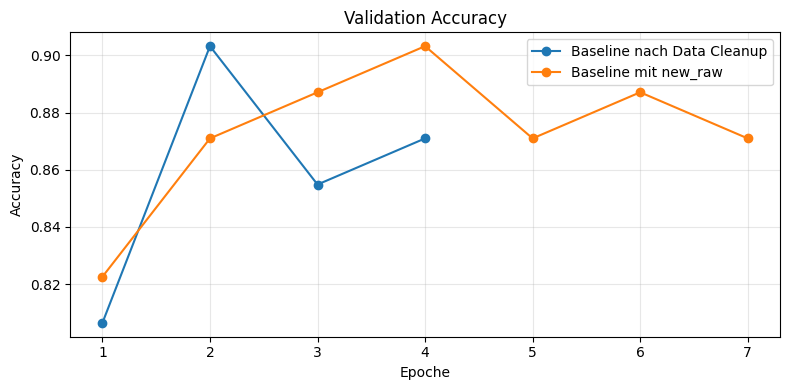

In [7]:
def plot_metric(histories, metric, title, ylabel):
    fig, ax = plt.subplots(figsize=(8, 4))
    plotted = False
    for name, hist in histories.items():
        if hist is not None and metric in hist.columns:
            ax.plot(hist.index + 1, hist[metric], marker="o", label=name)
            plotted = True
    ax.set_title(title)
    ax.set_xlabel("Epoche")
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    if not plotted:
        print(f"Keine Daten für {metric} gefunden.")
    else:
        plt.show()

plot_metric(histories, "loss",         "Training Loss",       "Loss")
plot_metric(histories, "val_loss",     "Validation Loss",     "Loss")
plot_metric(histories, "accuracy",     "Training Accuracy",   "Accuracy")
plot_metric(histories, "val_accuracy", "Validation Accuracy", "Accuracy")

## 6. Vergleich der finalen Trainingsläufe

In [8]:
rows = []
for name, hist in histories.items():
    if hist is None or hist.empty:
        rows.append({
            "Modellname":           name,
            "Datenstand":           "nicht geladen",
            "wichtigste Val-Metrik": None,
            "kurze Entscheidung":   "history.json fehlt",
        })
        continue
    best_val_acc   = hist["val_accuracy"].max()  if "val_accuracy" in hist else float("nan")
    final_val_loss = hist["val_loss"].iloc[-1]   if "val_loss"     in hist else float("nan")
    rows.append({
        "Modellname":           name,
        "Datenstand":           "Data Cleanup + new_raw" if "new_raw" in name else "Data Cleanup",
        "wichtigste Val-Metrik": f"best val_accuracy={best_val_acc:.3f}, final val_loss={final_val_loss:.3f}",
        "kurze Entscheidung":   "final gewählt" if "new_raw" in name else "Vergleichsbaseline",
    })

pd.DataFrame(rows)

,Modellname,Datenstand,wichtigste Val-Metrik,kurze Entscheidung
0,Baseline nach Data Cleanup,Data Cleanup,"best val_accuracy=0.903, final val_loss=0.422",Vergleichsbaseline
1,Baseline mit new_raw,Data Cleanup + new_raw,"best val_accuracy=0.903, final val_loss=0.360",final gewählt


## Modell-Pipeline

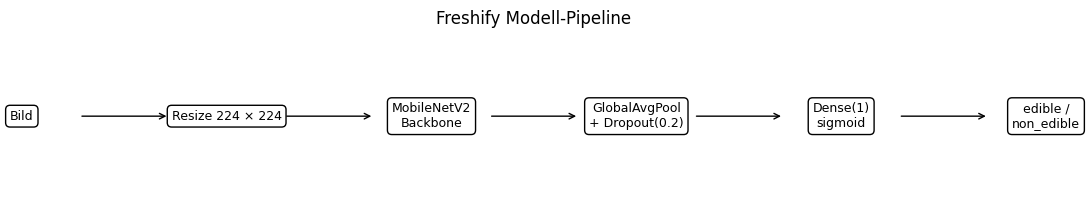

In [9]:
pipeline_steps = [
    "Bild",
    "Resize 224 × 224",
    "MobileNetV2\nBackbone",
    "GlobalAvgPool\n+ Dropout(0.2)",
    "Dense(1)\nsigmoid",
    "edible /\nnon_edible",
]

fig, ax = plt.subplots(figsize=(11, 2.2))
ax.axis("off")
n = len(pipeline_steps)
for i, step in enumerate(pipeline_steps):
    x = i / (n - 1)
    ax.text(x, 0.5, step, ha="center", va="center",
            bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="black"), fontsize=9)
    if i < n - 1:
        ax.annotate("",
                    xy=((i + 0.72) / (n - 1), 0.5),
                    xytext=((i + 0.28) / (n - 1), 0.5),
                    arrowprops=dict(arrowstyle="->"))
ax.set_title("Freshify Modell-Pipeline")
plt.tight_layout()
plt.show()

## 7. Detector-Kontext

Der Freshify-Classifier ist Teil einer mehrstufigen Pipeline. Der Detector (`src/detector.py`) segmentiert zuerst Objekte mit MobileSAM, filtert mit EfficientNetB0 (ImageNet) grob auf Food-Klassen und reicht dann die Crops an den Freshify-Classifier weiter.

In [10]:
detector_path = PROJECT_ROOT / "src" / "detector.py"
print(f"Detector-Code vorhanden: {detector_path.exists()} ({detector_path})")

pd.DataFrame([
    {"Komponente": "MobileSAM",                  "Rolle": "Segmentiert mögliche Objekte im Eingabebild."},
    {"Komponente": "EfficientNetB0 (ImageNet)",  "Rolle": "Prüft Crops grob auf Food-Klassen; nicht der Freshify edible/non_edible Classifier."},
    {"Komponente": "NMS",                         "Rolle": "Filtert überlappende Segmentvorschläge."},
    {"Komponente": "Freshify Classifier",         "Rolle": "Bewertet anschließend Lebensmittelzustand als edible oder non_edible."},
])

Detector-Code vorhanden: True (/Users/timwalther/food_freshness/src/detector.py)


,Komponente,Rolle
0,MobileSAM,Segmentiert mögliche Objekte im Eingabebild.
1,EfficientNetB0 (ImageNet),Prüft Crops grob auf Food-Klassen; nicht der Freshify edible/non_edible Classifier.
2,NMS,Filtert überlappende Segmentvorschläge.
3,Freshify Classifier,Bewertet anschließend Lebensmittelzustand als edible oder non_edible.


### Interpretation

- **Transfer Learning sinnvoll:** Der Datensatz ist klein — MobileNetV2 bringt bereits generische Bildmerkmale mit, die nicht neu gelernt werden müssen.
- **Leichtgewichtiges Modell:** Weniger Trainingsaufwand, schnellere Inferenz und einfachere Integration als komplexe Architekturen — passend für den ML4B-Prototyp.
- **Echte Smartphonebilder > synthetische Daten:** Reale Fotos verbessern die Robustheit gegenüber Beleuchtung, Bildwinkel und Hintergrund stärker als unkontrolliert generierte Bilder.
- **Finales Modell:** `baseline with new_raw`, weil dieser Datenstand näher am späteren Nutzungskontext liegt.